# BTSP on a linear track (1-compartment neurons)

**Objective:** Compare hyperparameters and evaluate spatial features pyramidal neurons learn to encode.

* Linear track (periodic)
* Agent set to travel in one direction along the track, reseting at the end.
* Pyramidal neuron layer:
  * Input from uniformly distributed Gaussian place cells (plastic)
  * 1 or multiple pyramidal neurons
* Learning:
  * BTSP learning: strong learning with a broad kernel, induced externally or occurring when a neuron's activation passes a predetermined threshold.
  * Hebbian learning (optional)

In [1]:
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox

from predhpc import agent, run_manager, plot_fcts
from predhpc.neurons import riab_neurons, learning_neurons, two_comp_neurons, object_neurons
from predhpc.util import learn_util, plot_util, params_util

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
warnings.filterwarnings(
    "ignore", message="solid 1D boundary", category=UserWarning
)
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [4]:
import importlib
importlib.reload(agent)
importlib.reload(learning_neurons)
importlib.reload(object_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(learn_util)
importlib.reload(params_util);

## Functions

In [5]:
def learn(env_params=None, agent_params=None, PC_params=None, 
          Pyr_params=None, num_rewards=200, max_num_steps=5000, 
          use_Hebbian=False, BTSP_after_num_target_reaches=5, 
          two_compartment=False):
    
    if env_params is None:
        env_params = params_util.get_env_params(environment="linear")
        
    if agent_params is None:
        agent_params = params_util.get_agent_params(environment="linear")

    if PC_params is None:
        PC_params = params_util.get_PC_params(environment="linear")

    if Pyr_params is None:
        Pyr_params = params_util.get_Pyr_params(
            environment="linear", two_compartment=two_compartment, BTSP=True
        )

    print_vals = {
        "Environment scale": env_params["scale"],
        "Agent dt": agent_params["dt"],
        "Agent target position": agent_params["target_position"],
        "# PCs": PC_params["n"], 
        "# Pyrs": Pyr_params["n"], 
        "Pyr. init at 0": Pyr_params["init_weights_zero"], 
        "Pyr. init scale": Pyr_params["w_init_scale"], 
        "Pyr. BTSP tau": Pyr_params["BTSP_filter_tau"], 
        "# rewards": num_rewards, 
        "Max # steps": max_num_steps, 
        "Hebbian learning": use_Hebbian, 
        "BTSP occurs after X number of target reaches": BTSP_after_num_target_reaches,
        "Two-compartment": two_compartment,
    }
    print_vals = [
        f"{name:16}: {value}" for name, value in print_vals.items()
    ]
    print("{}\n".format('\n'.join(print_vals)))
    
    Pyrs, spatial_axes, time_axes = run_manager.learn_1D_BTSP(
        env_params,
        agent_params,
        PC_params,
        Pyr_params,
        num_rewards=num_rewards,
        max_num_steps=max_num_steps,
        use_Hebbian=use_Hebbian,
        BTSP_after_num_target_reaches=BTSP_after_num_target_reaches,
        two_compartment=two_compartment,
    )
    
    return Pyrs, spatial_axes, time_axes

## 1. Only 1 Pyr. neuron
BTSP induced externally at target location (after the 4th encounter).  
Hebbian learning is disabled.

In [6]:
NUM_REWARDS = 8
MAX_NUM_STEPS = 10000

USE_HEBBIAN = False

agent_params = params_util.get_agent_params(
    environment="linear",
    target_position=params_util.SCALE_LINEAR / 2,
)

Pyr_params_one = params_util.get_Pyr_params(
    n=1, environment="linear", 
    two_compartment=False, BTSP=True, NMDA=False,
    init_weights_zero=False,
    w_init_scale=0,
    normalize_weights_divisively=True,
    post_BTSP_filter_tau="half",
)

Environment scale: 4.0
Agent dt        : 0.03
Agent target position: 2.0
# PCs           : 32
# Pyrs          : 1
Pyr. init at 0  : False
Pyr. init scale : 0
Pyr. BTSP tau   : 4
# rewards       : 8
Max # steps     : 10000
Hebbian learning: False
BTSP occurs after X number of target reaches: 3
Two-compartment : False



100%|███████████████████████████████████| 10000/10000 [00:02<00:00, 3708.67it/s]


Only reached the reward 6 times (target: 8).
Trajectory lengths (7) to date: 42.86 +/- 14.01 sec each
Trajectory lengths (7) to date: 1428.57 +/- 466.84 steps each


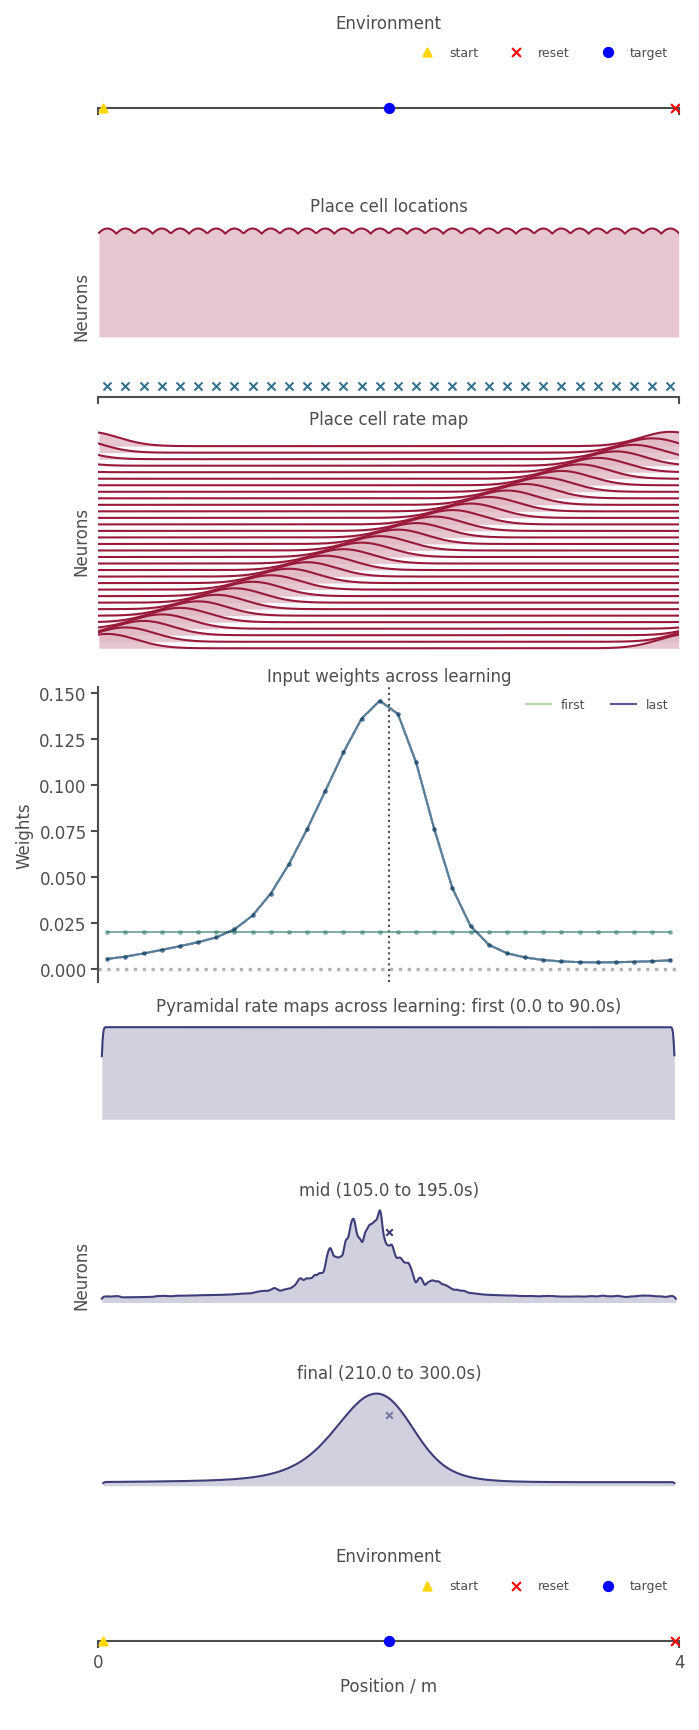

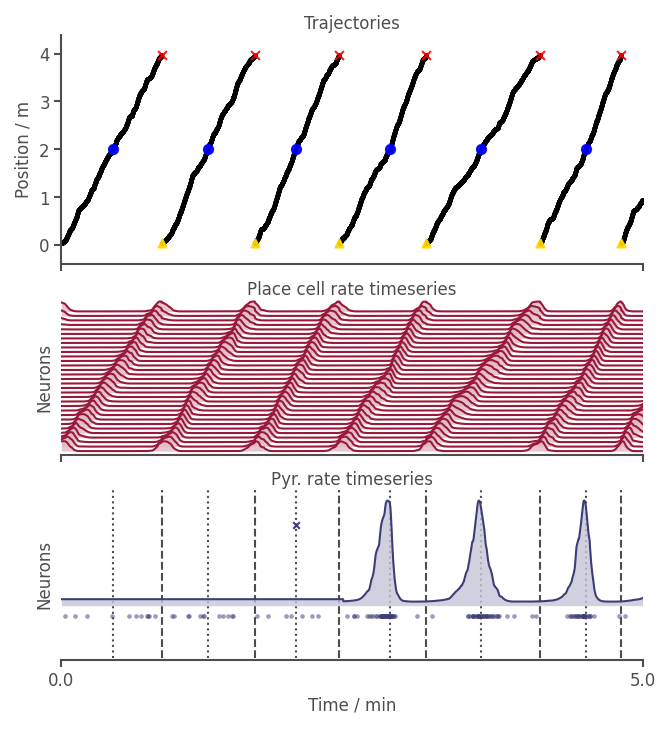

In [7]:
Pyrs, spatial_axes, time_axes = learn(
    agent_params=agent_params,
    Pyr_params=Pyr_params_one, 
    num_rewards=NUM_REWARDS, 
    max_num_steps=MAX_NUM_STEPS,
    use_Hebbian=USE_HEBBIAN,
    BTSP_after_num_target_reaches=3,
    two_compartment=False,
)

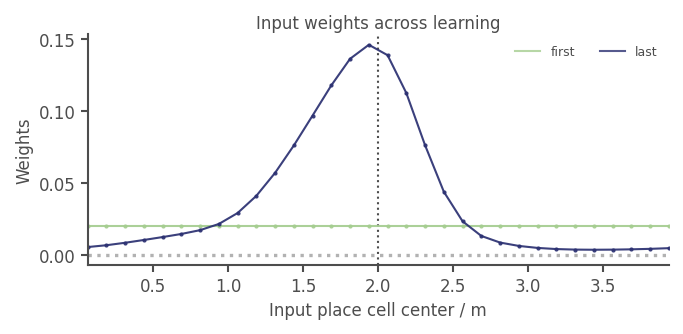

In [8]:
ws = [Pyrs.inputs["PCs"][key] for key in ["w_init", "w"]]
plot_fcts.plot_1D_input_place_cell_weights(ws, Pyrs.inputs["PCs"]["layer"]);

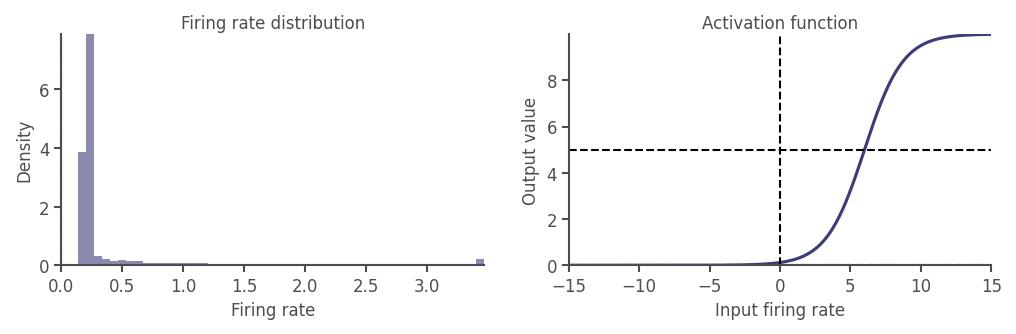

In [9]:
fig, ax1D = plt.subplots(1, 2, figsize=(8, 2))
Pyrs.plot_firingrate_distribution(sub_ax=ax1D[0]);
Pyrs.plot_activation_function(sub_ax=ax1D[1]);

### BTSP filters

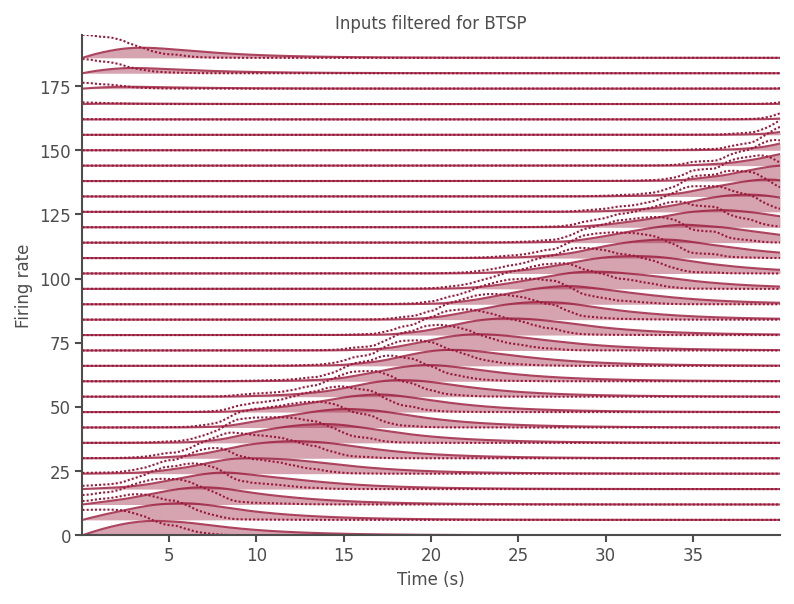

In [10]:
Pyrs.plot_filtered_for_BTSP("PCs", t_end=40);

BTSP events applied after 819.00 steps (24.57 sec.) (num steps: 819).


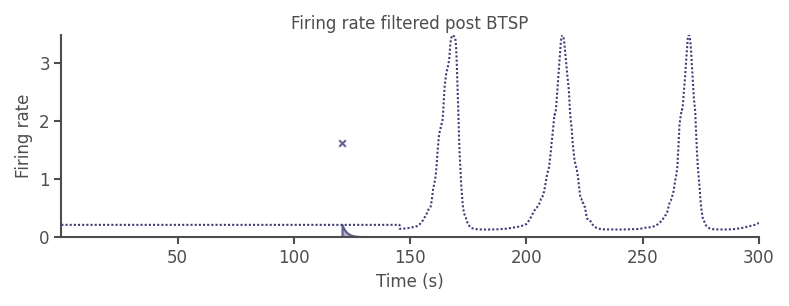

In [11]:
Pyrs.log_num_steps_to_apply_BTSP()
Pyrs.plot_filtered_for_BTSP();

## 2. Multiple Pyr. neurons
BTSP induced externally at for two neurons: (1) at the target location, and (2) at the start location (in each case, after the 3rd encounter).  
Hebbian learning is enabled (**much** weaker than BTSP).

In [12]:
importlib.reload(run_manager)
importlib.reload(learn_util)
importlib.reload(params_util)
importlib.reload(learning_neurons);

In [13]:
NUM_REWARDS = 16
MAX_NUM_STEPS = 10000

USE_HEBBIAN = True
W_INIT_SCALE = 0.005

agent_params = params_util.get_agent_params(
    environment="linear",
    target_position=params_util.SCALE_LINEAR / 2,
)

Pyr_params_mult = params_util.get_Pyr_params(
    n=4, environment="linear", 
    two_compartment=False, BTSP=True, NMDA=False,
    init_weights_zero=False,
    normalize_weights_divisively=True,
    w_init_scale=W_INIT_SCALE,
)

Environment scale: 4.0
Agent dt        : 0.03
Agent target position: 2.0
# PCs           : 32
# Pyrs          : 4
Pyr. init at 0  : False
Pyr. init scale : 0.005
Pyr. BTSP tau   : 4
# rewards       : 16
Max # steps     : 10000
Hebbian learning: True
BTSP occurs after X number of target reaches: 3
Two-compartment : False



100%|███████████████████████████████████| 10000/10000 [00:03<00:00, 3249.76it/s]


Only reached the reward 6 times (target: 16).
Trajectory lengths (6) to date: 50.00 +/- 6.67 sec each
Trajectory lengths (6) to date: 1666.67 +/- 222.42 steps each


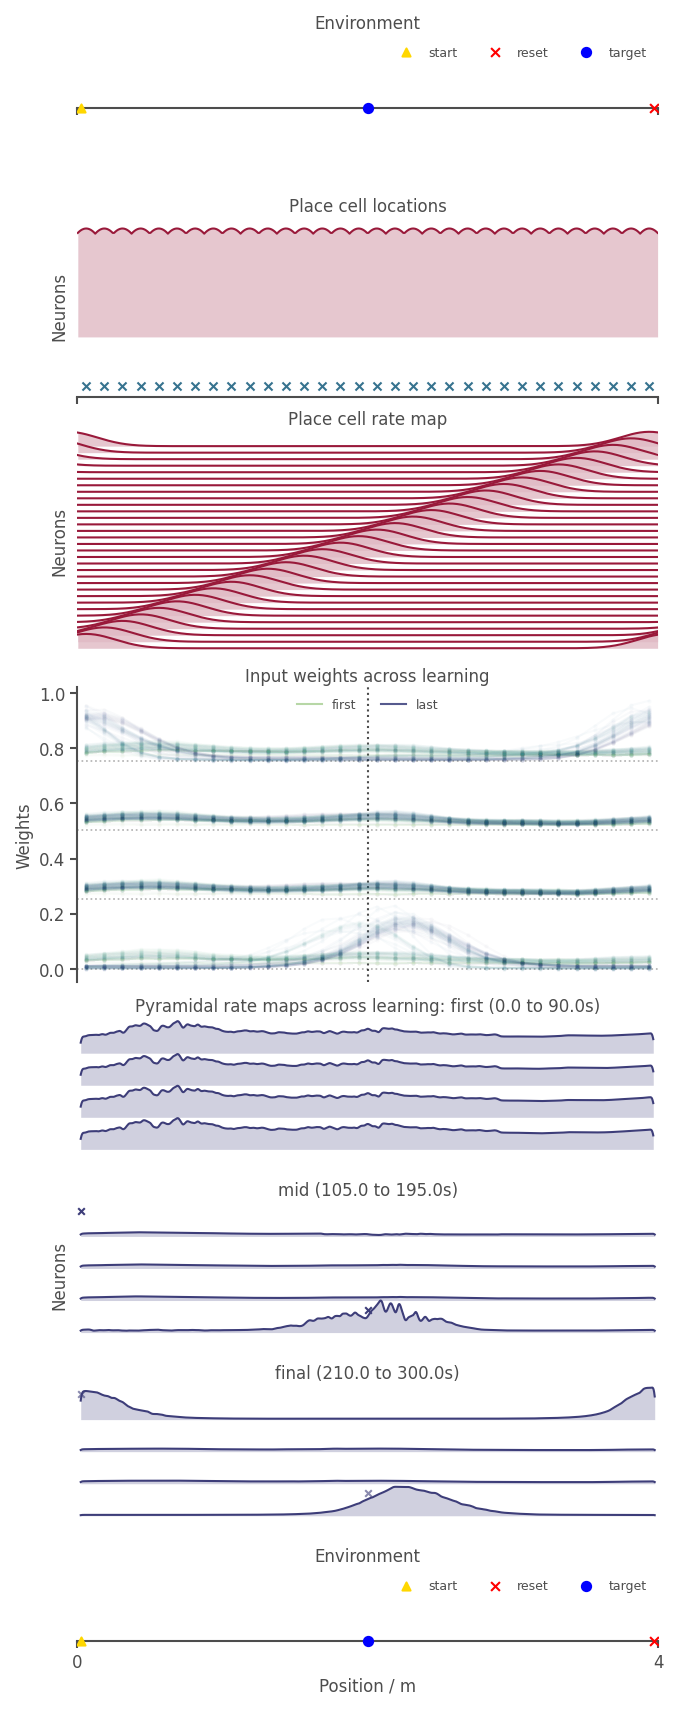

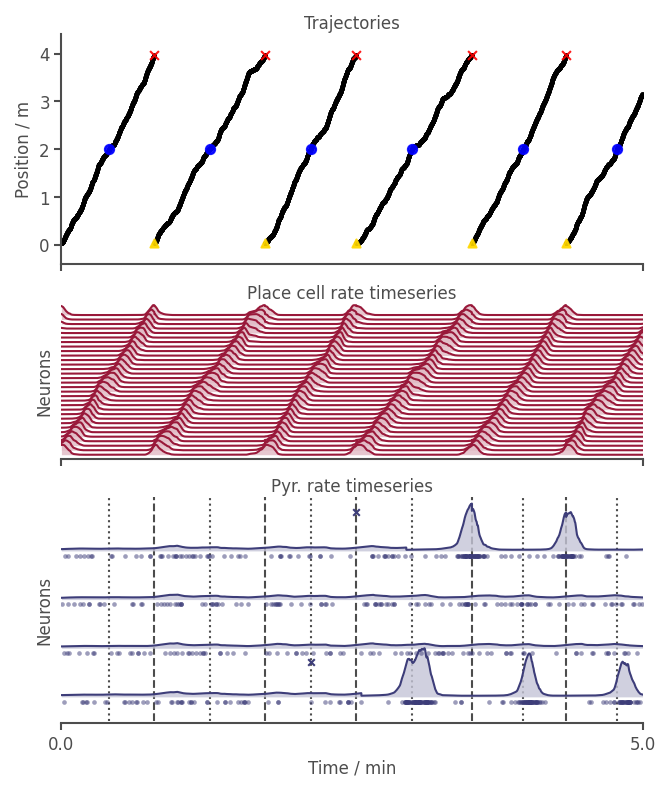

In [14]:
Pyrs, spatial_axes, time_axes = learn(
    agent_params=agent_params,
    Pyr_params=Pyr_params_mult,
    num_rewards=NUM_REWARDS, 
    max_num_steps=MAX_NUM_STEPS,
    use_Hebbian=USE_HEBBIAN,
    BTSP_after_num_target_reaches=3,
    two_compartment=False,
)

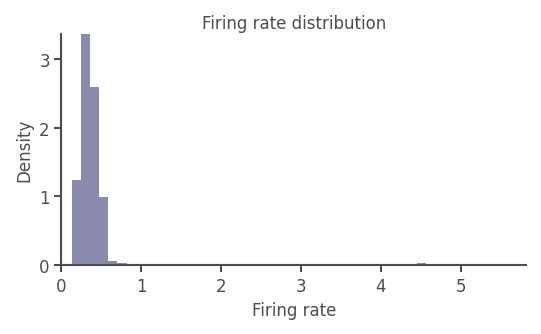

In [15]:
Pyrs.plot_firingrate_distribution();

#### BTSP filters

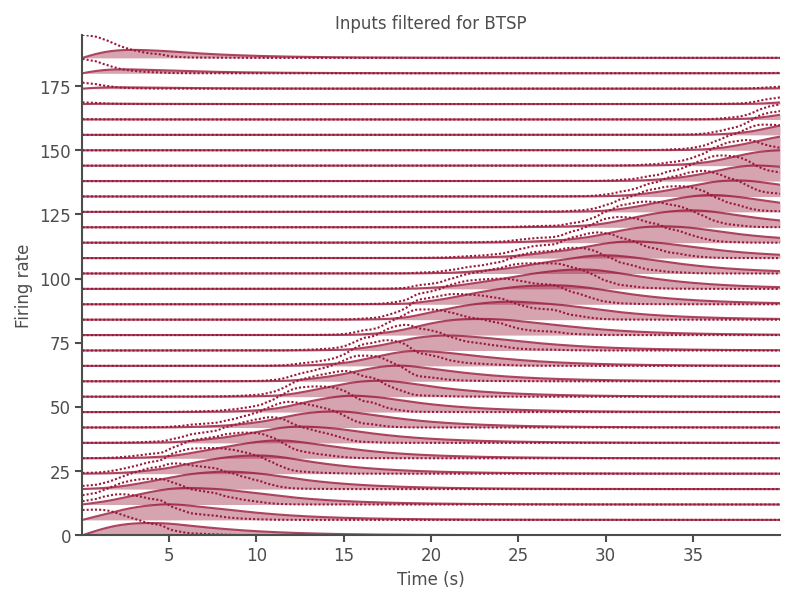

In [16]:
Pyrs.plot_filtered_for_BTSP("PCs", t_start=0, t_end=40);

BTSP events applied after 863.50 steps (25.91 sec.) (num steps: 869, 858).


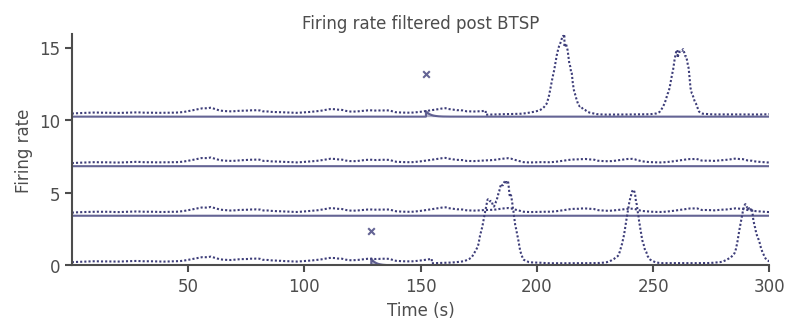

In [17]:
Pyrs.log_num_steps_to_apply_BTSP()
Pyrs.plot_filtered_for_BTSP();

## 3. Internally-generated BTSP
BTSP occurs the first time a neuron achieves a specific activity threshold.  
Hebbian learning is enabled, allowing threshold to eventually be reached.  
**Note:** Target position is irrelevant as it does not affect neural activity.

In [18]:
from predhpc import env

import importlib
importlib.reload(learning_neurons)
importlib.reload(run_manager)
importlib.reload(learn_util)
importlib.reload(plot_util)
importlib.reload(agent)

from tqdm import tqdm

In [19]:
MAX_NUM_STEPS = 40000 # many steps
W_INIT_SCALE = 0.1 # to enable BTSP to occur
REG_ALPHA = 0.75 # lower to enable BTSP

env_params = params_util.get_env_params(environment="linear")
agent_params = params_util.get_agent_params(environment="linear")
PC_params = params_util.get_PC_params(environment="linear")

Pyr_params = params_util.get_Pyr_params(
    n=1, environment="linear", 
    two_compartment=False, BTSP=True, 
    init_weights_zero=False,
    normalize_weights_divisively=True,
    w_init_scale=W_INIT_SCALE,
    regularization_alpha=REG_ALPHA,
    single_BTSP=True,
)

100%|███████████████████████████████████| 40000/40000 [00:14<00:00, 2673.62it/s]


1 BTSP event(s).


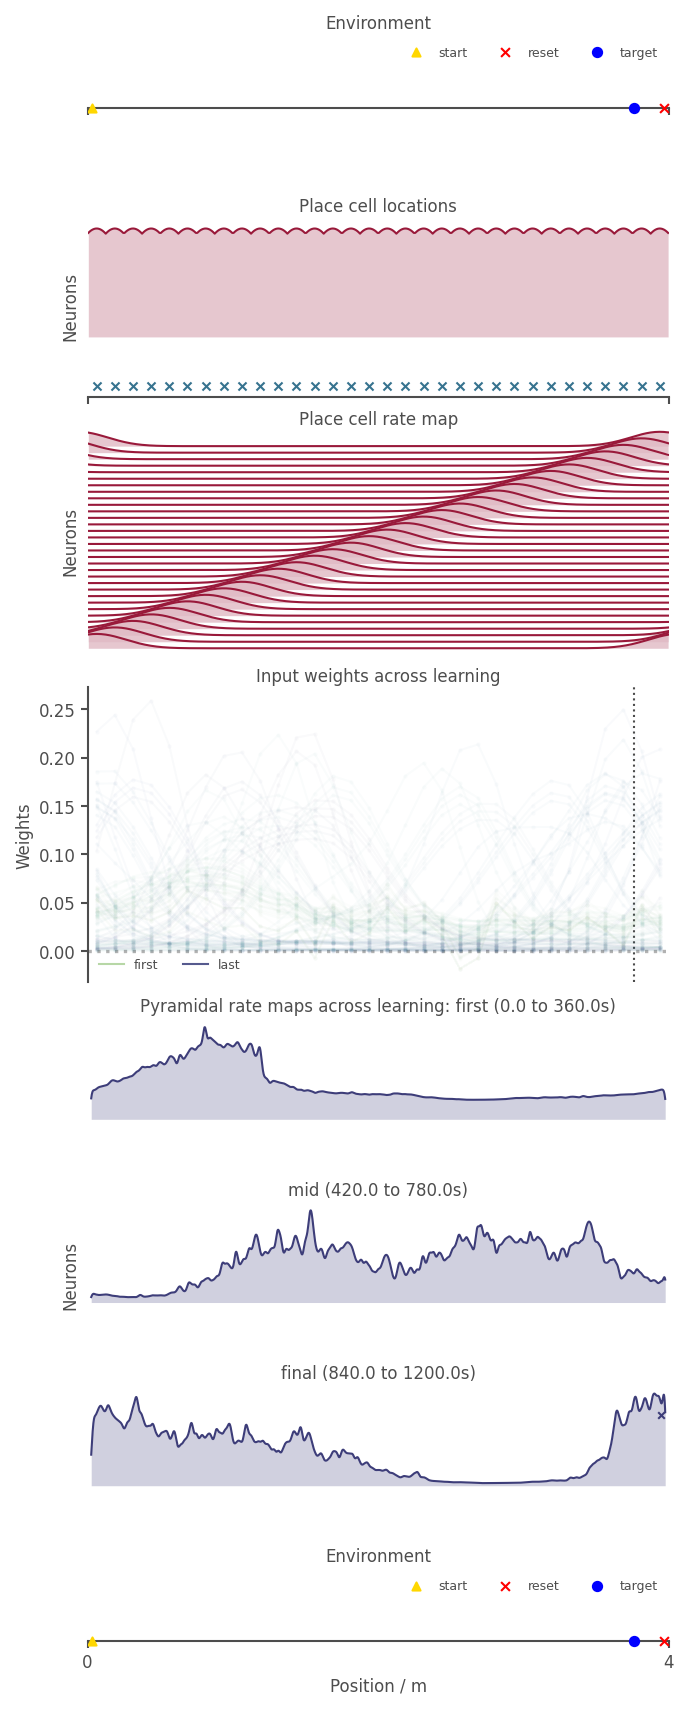

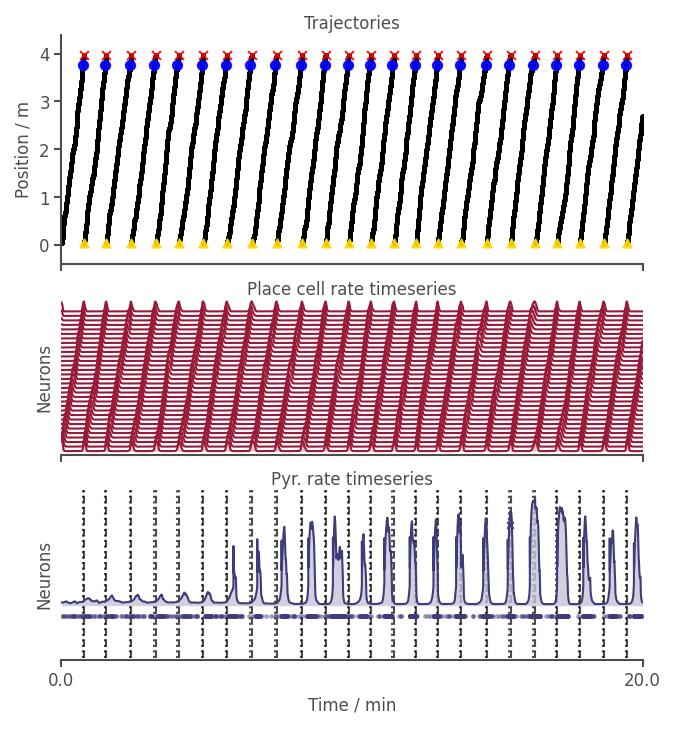

In [20]:
Env = env.Environment(params=env_params)

Ag = agent.ResetableAgent(Env, params=agent_params)
PCs = riab_neurons.PlaceCells(Ag, params=PC_params)

Pyr_params["input_layers"] = [PCs]
Pyrs = learning_neurons.NMDALayer(Ag, params=Pyr_params)
Pyrs.set_learn()
Pyrs.set_BTSP_learn()

num_BTSP = 0
Pyr_weights = [Pyrs.inputs[PCs.name]["w"].copy()]
for i in tqdm(range(MAX_NUM_STEPS)):
    Ag.update()
    PCs.update()
    Pyrs.update()
    if not i % (MAX_NUM_STEPS // 100):
        Pyr_weights.append(Pyrs.inputs[PCs.name]["w"].copy())

run_manager.plot_1D_spatial_info(Ag, PCs, Pyrs, Pyr_weights)
run_manager.plot_1D_time_info(Ag, PCs, Pyrs)

num_BTSP_events = len(Pyrs.history["BTSP_events"])
print(f"{num_BTSP_events} BTSP event(s).")

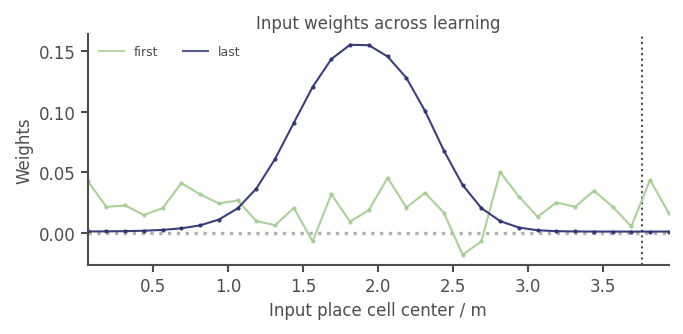

In [21]:
ws = [Pyrs.inputs["PCs"][key] for key in ["w_init", "w"]]
plot_fcts.plot_1D_input_place_cell_weights(ws, Pyrs.inputs["PCs"]["layer"]);

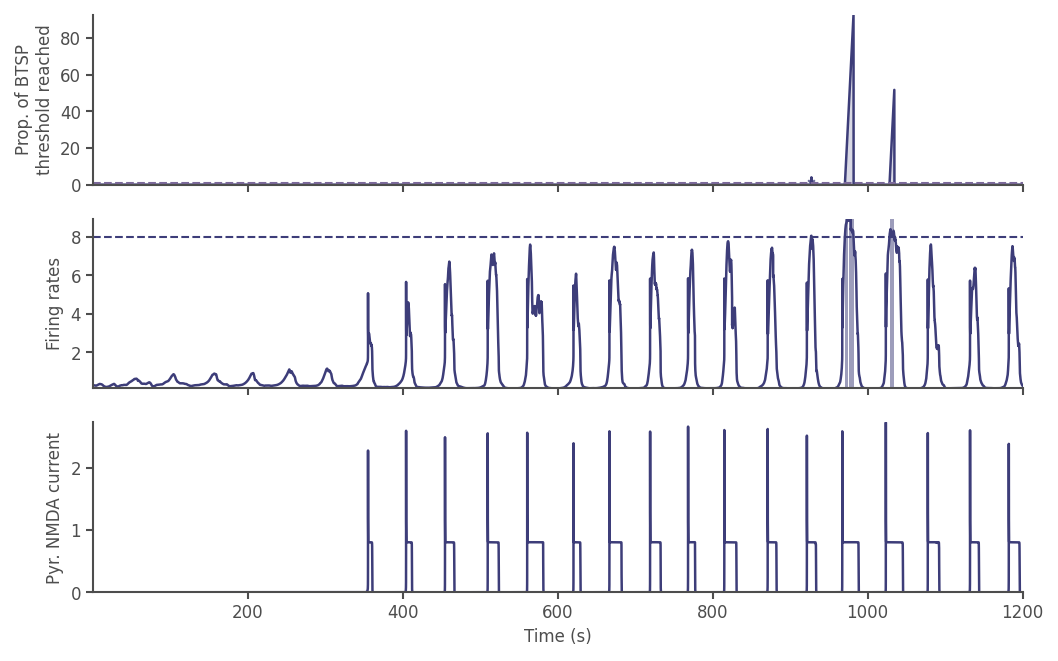

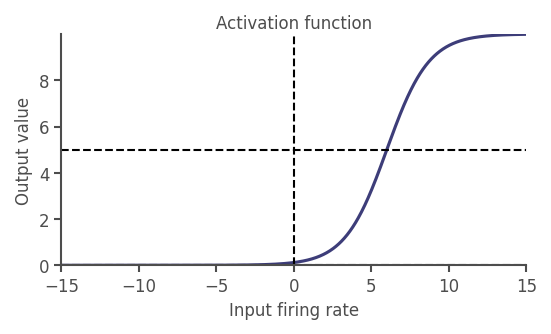

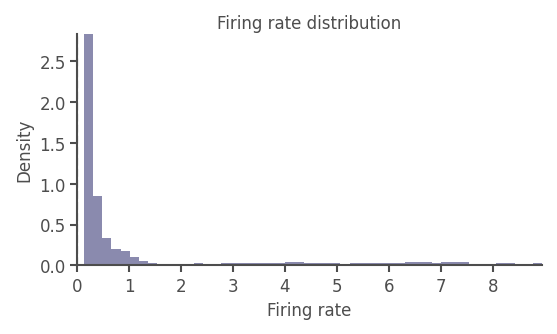

In [22]:
ax1D = Pyrs.plot_BTSP_ramp()
Pyrs.plot_activation_function()
Pyrs.plot_firingrate_distribution();

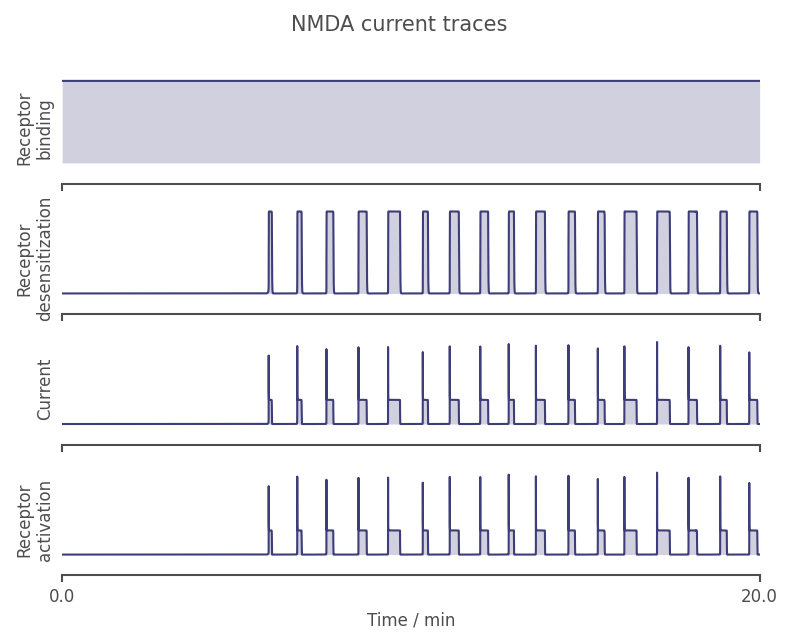

In [23]:
ax1D = Pyrs.NMDACurrent.plot_timeseries(datatypes="all")

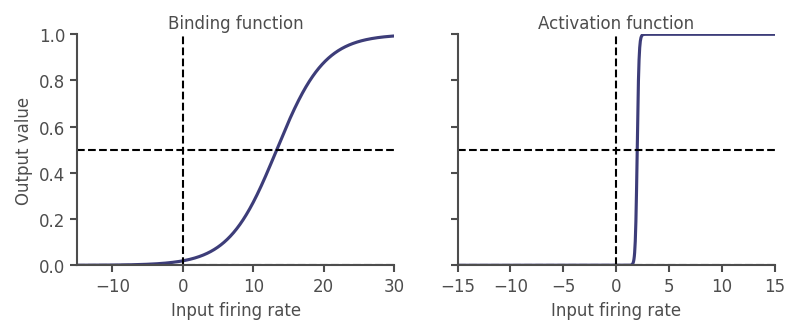

In [24]:
fig, ax1D = plt.subplots(1, 2, figsize=[6, 2], sharey=True)
Pyrs.NMDACurrent.plot_function("binding", max_input_fr=30, sub_ax=ax1D[0])
Pyrs.NMDACurrent.plot_function("activation", min_input_fr=-15, max_input_fr=15, sub_ax=ax1D[1])
ax1D[1].set_ylabel("");